In [1]:
!pip install pandas matplotlib openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create folder for graphs
os.makedirs("charts", exist_ok=True)

In [3]:
data = {
    "Intern_ID":[101,102,103,104,105,106,107,108,109,110],

    "Intern_Name":[
        "Ali","Sara","Ahmed","Ayesha","Bilal",
        "Fatima","Usman","Hina","Hamza","Noor"
    ],

    "Department":[
        "Data Science",
        "AI",
        "Web",
        "Data Science",
        "AI",
        "Web",
        "AI",
        "Data Science",
        "Web",
        "AI"
    ],

    "Task_Completion_Time(Days)":[
        5,7,4,6,8,3,5,4,7,6
    ],

    "Project_Quality(100)":[
        90,82,95,88,70,98,85,91,78,89
    ],

    "Mentor_Feedback(5)":[
        4.8,4.2,5.0,4.5,3.8,4.9,4.1,4.7,3.9,4.6
    ]
}

df = pd.DataFrame(data)

df.to_csv("intern_performance.csv", index=False)

df.head()

,Intern_ID,Intern_Name,Department,Task_Completion_Time(Days),Project_Quality(100),Mentor_Feedback(5)
0,101,Ali,Data Science,5,90,4.8
1,102,Sara,AI,7,82,4.2
2,103,Ahmed,Web,4,95,5.0
3,104,Ayesha,Data Science,6,88,4.5
4,105,Bilal,AI,8,70,3.8


In [4]:
df = pd.read_csv("intern_performance.csv")

df.head()

,Intern_ID,Intern_Name,Department,Task_Completion_Time(Days),Project_Quality(100),Mentor_Feedback(5)
0,101,Ali,Data Science,5,90,4.8
1,102,Sara,AI,7,82,4.2
2,103,Ahmed,Web,4,95,5.0
3,104,Ayesha,Data Science,6,88,4.5
4,105,Bilal,AI,8,70,3.8


In [5]:
print(df.isnull().sum())

Intern_ID                     0
Intern_Name                   0
Department                    0
Task_Completion_Time(Days)    0
Project_Quality(100)          0
Mentor_Feedback(5)            0
dtype: int64


In [6]:
max_days = df["Task_Completion_Time(Days)"].max()

df["Completion_Score"] = (
    (max_days - df["Task_Completion_Time(Days)"] + 1)
    / max_days
) * 100

df["Mentor_Feedback(100)"] = df["Mentor_Feedback(5)"] * 20

df["Overall_KPI"] = (
    df["Completion_Score"]*0.30 +
    df["Project_Quality(100)"]*0.40 +
    df["Mentor_Feedback(100)"]*0.30
)

df.head()

,Intern_ID,Intern_Name,Department,Task_Completion_Time(Days),Project_Quality(100),Mentor_Feedback(5),Completion_Score,Mentor_Feedback(100),Overall_KPI
0,101,Ali,Data Science,5,90,4.8,50.0,96.0,79.80
1,102,Sara,AI,7,82,4.2,25.0,84.0,65.50
2,103,Ahmed,Web,4,95,5.0,62.5,100.0,86.75
3,104,Ayesha,Data Science,6,88,4.5,37.5,90.0,73.45
4,105,Bilal,AI,8,70,3.8,12.5,76.0,54.55


In [7]:
def performance(score):

    if score >= 90:
        return "Excellent"

    elif score >= 80:
        return "Very Good"

    elif score >= 70:
        return "Good"

    else:
        return "Needs Improvement"

df["Performance"] = df["Overall_KPI"].apply(performance)

df.head()

,Intern_ID,Intern_Name,Department,Task_Completion_Time(Days),Project_Quality(100),Mentor_Feedback(5),Completion_Score,Mentor_Feedback(100),Overall_KPI,Performance
0,101,Ali,Data Science,5,90,4.8,50.0,96.0,79.80,Good
1,102,Sara,AI,7,82,4.2,25.0,84.0,65.50,Needs Improvement
2,103,Ahmed,Web,4,95,5.0,62.5,100.0,86.75,Very Good
3,104,Ayesha,Data Science,6,88,4.5,37.5,90.0,73.45,Good
4,105,Bilal,AI,8,70,3.8,12.5,76.0,54.55,Needs Improvement


In [8]:
df.to_csv("monthly_performance_report.csv", index=False)

print("Monthly Report Saved Successfully.")

Monthly Report Saved Successfully.


In [9]:
top = df.sort_values(
    by="Overall_KPI",
    ascending=False
)

top.head()

,Intern_ID,Intern_Name,Department,Task_Completion_Time(Days),Project_Quality(100),Mentor_Feedback(5),Completion_Score,Mentor_Feedback(100),Overall_KPI,Performance
5,106,Fatima,Web,3,98,4.9,75.0,98.0,91.10,Excellent
2,103,Ahmed,Web,4,95,5.0,62.5,100.0,86.75,Very Good
7,108,Hina,Data Science,4,91,4.7,62.5,94.0,83.35,Very Good
0,101,Ali,Data Science,5,90,4.8,50.0,96.0,79.80,Good
9,110,Noor,AI,6,89,4.6,37.5,92.0,74.45,Good


In [10]:
summary = df[[
    "Completion_Score",
    "Project_Quality(100)",
    "Mentor_Feedback(100)",
    "Overall_KPI"
]].mean()

print(summary)

Completion_Score        43.750
Project_Quality(100)    86.600
Mentor_Feedback(100)    89.000
Overall_KPI             74.465
dtype: float64


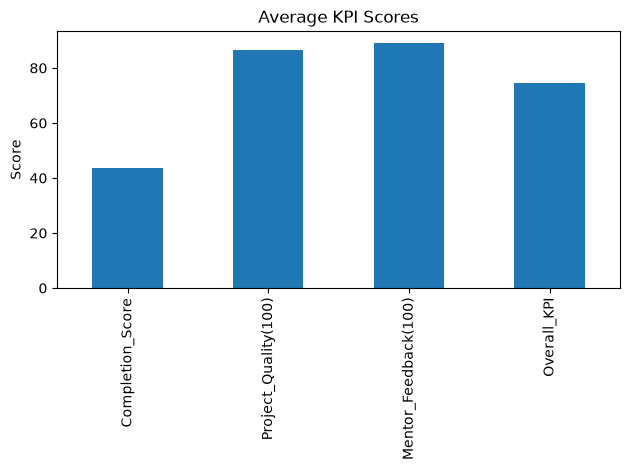

In [12]:
summary.plot(kind="bar")

plt.title("Average KPI Scores")

plt.ylabel("Score")

plt.tight_layout()

plt.savefig("average_kpi_scores.png")

plt.show()

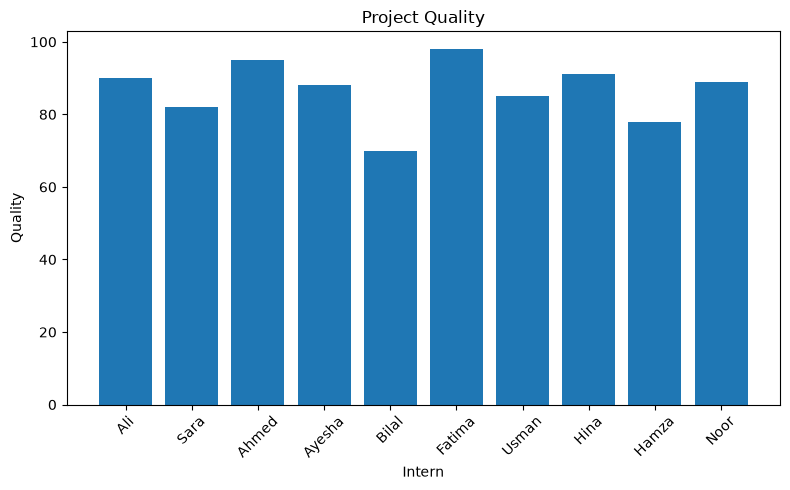

In [14]:
plt.figure(figsize=(8,5))

plt.bar(df["Intern_Name"], df["Project_Quality(100)"])

plt.title("Project Quality")

plt.xlabel("Intern")

plt.ylabel("Quality")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("project_quality.png")

plt.show()

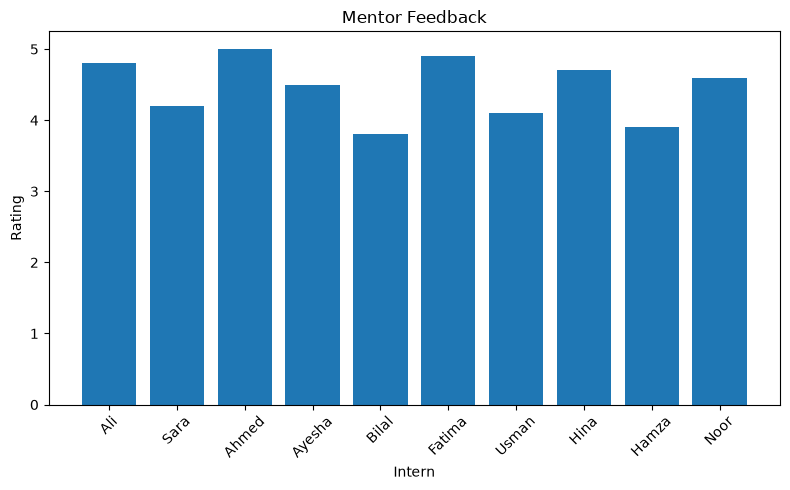

In [15]:
plt.figure(figsize=(8,5))

plt.bar(df["Intern_Name"], df["Mentor_Feedback(5)"])

plt.title("Mentor Feedback")

plt.xlabel("Intern")

plt.ylabel("Rating")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("mentor_feedback.png")

plt.show()

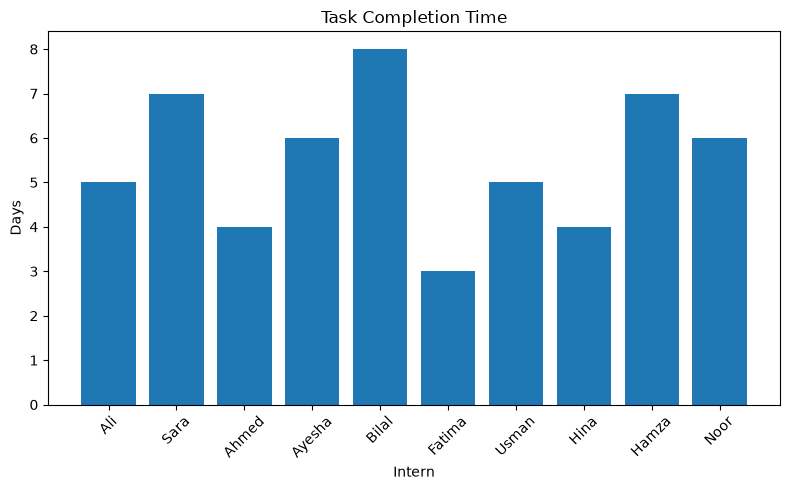

In [16]:
plt.figure(figsize=(8,5))

plt.bar(df["Intern_Name"], df["Task_Completion_Time(Days)"])

plt.title("Task Completion Time")

plt.xlabel("Intern")

plt.ylabel("Days")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("task_completion_time.png")

plt.show()

In [17]:
df.to_excel(
    "monthly_performance_report.xlsx",
    index=False
)

print("Excel Report Saved.")

Excel Report Saved.
